In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

ModuleNotFoundError: No module named 'sklearn'

In [1]:
import sys
print(sys.executable)

c:\Users\Amaan\anaconda3\python.exe


In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna(subset=["TotalCharges"])

customer_ids = df["customerID"].copy()

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(["customerID", "Churn"], axis=1)

X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Features:", X_encoded.shape)
print("Target:", y.shape)

Features: (7032, 30)
Target: (7032,)


In [5]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [7]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8038
Precision: 0.6476
Recall   : 0.5749
F1 Score : 0.6091
ROC-AUC  : 0.8356


In [11]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[916 117]
 [159 215]]


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)

X_train: (5625, 30)
X_test: (1407, 30)


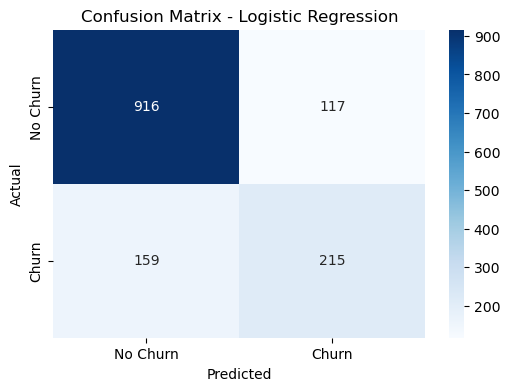

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

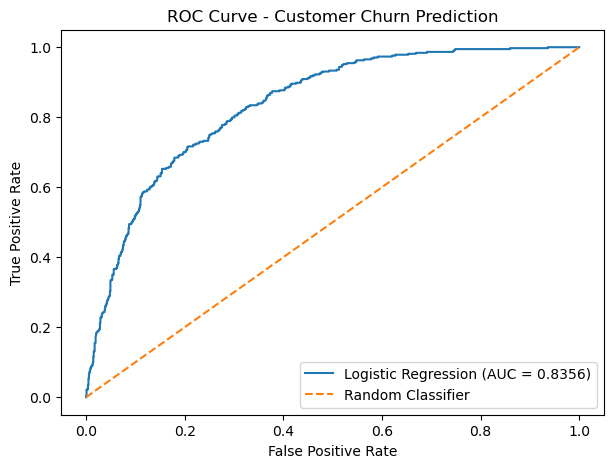

In [16]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Customer Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [17]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



# 📊 Logistic Regression Model — Results

## Model Performance

 Metric | Score |
---|---:|
 Accuracy | 80.38% |
 Precision | 64.76% |
 Recall | 57.49% |
 F1 Score | 60.91% |
 ROC-AUC | 83.56% |

## Business Interpretation

 The model achieved 80.38% overall accuracy.
 ROC-AUC of 83.56% indicates good ability to distinguish between churn and non-churn customers.
 Churn recall was 57.49%, meaning the model identified approximately 57% of actual churners.
 The confusion matrix showed 215 correctly identified churners and 159 missed churners.
 Improving churn recall could help the business identify more at-risk customers for targeted retention campaigns.